## Data Loading & Initial Exploration

The full Steam Reviews Dataset 2021 contains approximately 21 million reviews.
To make analysis feasible on local hardware, we have pre-sampled the dataset
by taking 12% of reviews from each game (grouped by app_id), resulting in a
representative sample of approximately 2.6 million rows across 315 games.

In this Notebook we:
* Load the pre-sampled parquet file
* Select only the columns relevant to text mining
* Filter for English-language reviews
* Perform a thorough data quality audit
* Document key statistics that will inform all downstream analysis

### Import Libraries & Configure Display Settings

We load all necessary libraries for data loading, manipulation and visualization.
Display settings are configured so that all columns and full text content are
visible when inspecting the dataframe.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 150)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("Libraries loaded")

Libraries loaded


### Load the Pre-Sampled Parquet File

We load the parquet file created in the behavioral analysis part, which was constructed
by sampling 12% of reviews from each game (grouped by app_id) from the
full 21 million row dataset.

We immediately inspect the shape, column names, and data types to confirm
the file loaded correctly and understand what we are working with.

### From the output of the next cell,
* Total number of rows are 2,609,677
* Total columns are 23

In [2]:
df_full = pd.read_parquet('../data/steam_reviews_sampled.parquet')  

print(f"Total rows     : {len(df_full):,}")
print(f"Total columns  : {df_full.shape[1]}")
print(f"Memory usage   : {df_full.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nColumn names:\n{df_full.columns.tolist()}")

Total rows     : 2,609,677
Total columns  : 23
Memory usage   : 1011.5 MB

Column names:
['Unnamed: 0', 'app_id', 'app_name', 'review_id', 'language', 'review', 'timestamp_created', 'timestamp_updated', 'recommended', 'votes_helpful', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'written_during_early_access', 'author.steamid', 'author.num_games_owned', 'author.num_reviews', 'author.playtime_forever', 'author.playtime_last_two_weeks', 'author.playtime_at_review', 'author.last_played']


### Inspecting the Data

Below is the high level view of the raw data. We make use of this to filter or select the right columns that might be required for out Text Analysis.
Viewing a sample of rows alongside data types and summary statistics helps us
understand the structure of the dataset and spot any immediate quality issues.

In [3]:
df_full.head(5)

,Unnamed: 0,app_id,app_name,review_id,language,review,timestamp_created,timestamp_updated,recommended,votes_helpful,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,author.steamid,author.num_games_owned,author.num_reviews,author.playtime_forever,author.playtime_last_two_weeks,author.playtime_at_review,author.last_played
0,483066,70,Half-Life,67466662,english,games lit,1587088761,1587088761,True,0,0,0.49,0,True,False,False,76561198393674381,70,7,468.00,0.00,327.00,"1,587,146,640.00"
1,482926,70,Half-Life,67630987,english,fun game,1587307934,1587307934,True,0,0,0.00,0,True,False,False,76561198124244032,40,1,"4,384.00",0.00,"4,375.00","1,587,337,064.00"
2,491793,70,Half-Life,60621817,english,Classic,1577393132,1577393132,True,0,0,0.00,0,True,False,False,76561198184787194,55,2,"1,942.00",0.00,"1,122.00","1,577,485,023.00"
3,473102,70,Half-Life,81085377,turkish,Desinc izlemeden oynamayın.,1606667257,1606667257,True,0,0,0.00,0,True,False,False,76561198211172345,242,64,"1,485.00",0.00,"1,411.00","1,608,133,624.00"
4,476284,70,Half-Life,76039982,english,""" Why do we have tower these ridicoulous ties ? """,1600206820,1600206820,True,0,0,0.00,0,True,False,False,76561198352005275,23,3,"3,340.00",0.00,"2,883.00","1,602,516,534.00"


In [4]:
df_full.dtypes

Unnamed: 0                          int64
app_id                              int64
app_name                              str
review_id                           int64
language                              str
review                                str
timestamp_created                   int64
timestamp_updated                   int64
recommended                          bool
votes_helpful                       int64
votes_funny                         int64
weighted_vote_score               float64
comment_count                       int64
steam_purchase                       bool
received_for_free                    bool
written_during_early_access          bool
author.steamid                      int64
author.num_games_owned              int64
author.num_reviews                  int64
author.playtime_forever           float64
author.playtime_last_two_weeks    float64
author.playtime_at_review         float64
author.last_played                float64
dtype: object

In [5]:
df_full.describe(include='all')

,Unnamed: 0,app_id,app_name,review_id,language,review,timestamp_created,timestamp_updated,recommended,votes_helpful,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,author.steamid,author.num_games_owned,author.num_reviews,author.playtime_forever,author.playtime_last_two_weeks,author.playtime_at_review,author.last_played
count,"2,609,677.00","2,609,677.00",2609677,"2,609,677.00",2609677,2605593,"2,609,677.00","2,609,677.00",2609677,"2,609,677.00","2,609,677.00","2,609,677.00","2,609,677.00",2609677,2609677,2609677,"2,609,677.00","2,609,677.00","2,609,677.00","2,609,677.00","2,609,677.00","2,606,619.00","2,609,677.00"
unique,NaN,NaN,315,NaN,28,2117170,NaN,NaN,2,NaN,NaN,NaN,NaN,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,PLAYERUNKNOWN'S BATTLEGROUNDS,NaN,english,good,NaN,NaN,True,NaN,NaN,NaN,NaN,True,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,197311,NaN,1156152,12836,NaN,NaN,2282935,NaN,NaN,NaN,NaN,2020392,2527394,2367546,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,"10,873,698.77","392,817.55",NaN,"51,867,104.43",NaN,NaN,"1,544,414,477.09","1,547,554,384.87",NaN,1.89,"139,892.56",0.17,0.13,NaN,NaN,NaN,"76,561,198,300,768,960.00","1,685,416.53",10.51,"16,122.80",156.86,"8,827.39","1,580,509,230.41"
std,"6,277,870.82","248,097.85",NaN,"20,843,353.71",NaN,NaN,"58,116,040.19","56,891,412.34",NaN,40.77,"24,511,447.30",0.24,1.88,NaN,NaN,NaN,"317,797,255.94","2,722,490,913.14",34.13,"37,616.77",735.18,"23,991.73","46,853,672.26"
min,6.00,70.00,NaN,212.00,NaN,NaN,"1,290,206,593.00","1,290,206,593.00",NaN,0.00,0.00,0.00,0.00,NaN,NaN,NaN,"76,561,197,960,265,744.00",0.00,1.00,0.00,0.00,1.00,0.00
25%,"5,437,000.00","242,760.00",NaN,"36,374,020.00",NaN,NaN,"1,510,143,862.00","1,511,726,198.00",NaN,0.00,0.00,0.00,0.00,NaN,NaN,NaN,"76,561,198,071,392,016.00",22.00,2.00,"1,251.00",0.00,559.00,"1,573,349,942.00"
50%,"10,873,587.00","359,550.00",NaN,"53,825,073.00",NaN,NaN,"1,562,437,315.00","1,572,179,676.00",NaN,0.00,0.00,0.00,0.00,NaN,NaN,NaN,"76,561,198,176,534,672.00",61.00,4.00,"4,307.00",0.00,"1,880.00","1,599,078,540.00"
75%,"16,310,359.00","578,080.00",NaN,"69,275,618.00",NaN,NaN,"1,589,676,784.00","1,591,380,727.00",NaN,1.00,0.00,0.48,0.00,NaN,NaN,NaN,"76,561,198,379,300,864.00",145.00,10.00,"14,927.00",0.00,"6,841.00","1,609,008,378.00"


### Select Columns Relevant to Text Mining

The full dataset contains 23 columns, many of which are not relevant to
text mining. Loading all columns unnecessarily increases memory usage and
adds noise to the analysis.

We select only the 8 columns that are directly needed for our text mining
objectives:
- **review**: the raw text we will analyze
- **recommended**: our primary classification target
- **votes_helpful**: our helpfulness prediction target
- **language**: needed to filter English reviews
- **written_during_early_access**: contextual feature for modeling
- **author.playtime_at_review**: behavioral feature at time of writing
- **author.num_reviews**: reviewer credibility signal
- **app_name**: for readable grouping and per-game analysis

In [6]:
cols_needed = [
    'review_id',
    'review',
    'recommended',
    'votes_helpful',
    'language',
    'written_during_early_access',
    'author.playtime_at_review',
    'author.num_reviews',
    'app_name',
    'app_id',
]

df = df_full[cols_needed].copy()

print(f"Columns selected : {df.shape[1]}")
print(f"Shape            : {df.shape}")
print(f"\n{df.dtypes}")

Columns selected : 10
Shape            : (2609677, 10)

review_id                        int64
review                             str
recommended                       bool
votes_helpful                    int64
language                           str
written_during_early_access       bool
author.playtime_at_review      float64
author.num_reviews               int64
app_name                           str
app_id                           int64
dtype: object


### Filter English-Only Reviews

The NLP pipeline for this project follows tokenization, stopword removal, and lemmatization is
built for English text. Non-English reviews would produce meaningless tokens
and corrupt our topic models and frequency analysis.

We inspect the language distribution first to understand how multilingual
the dataset is, then filter to retain only English reviews.

In [7]:
print("Language Distribution which are Top 15")
lang_counts = df['language'].value_counts().head(15)
lang_pct    = df['language'].value_counts(normalize=True).mul(100).round(1).head(15)
print(pd.DataFrame({'count': lang_counts, 'percent': lang_pct}))

Language Distribution which are Top 15
             count  percent
language                   
english    1156152    44.30
schinese    451258    17.30
russian     281324    10.80
brazilian   100681     3.90
spanish      97789     3.70
german       90344     3.50
turkish      76908     2.90
koreana      73895     2.80
french       65049     2.50
polish       59453     2.30
tchinese     26094     1.00
czech        16063     0.60
italian      15897     0.60
thai         15437     0.60
japanese      9893     0.40


In [8]:
df = df[df['language'] == 'english'].copy()
df = df.drop(columns=['language'])

print(f"\nRows after English filter : {len(df):,}")
print(f"Columns remaining         : {df.shape[1]}")


Rows after English filter : 1,156,152
Columns remaining         : 9


### Null values summary & Junk Review Removal

Before any analysis, we audit every column for missing values. Null reviews
cannot be processed by our NLP pipeline and must be removed. We also remove
reviews that are effectively empty, those consisting of only whitespace or
fewer than 3 words as they carry no meaningful textual content.

We document exactly how many rows are removed at each step for full transparency.

In [9]:

null_summary = pd.DataFrame({
    'missing_count' : df.isnull().sum(),
    'missing_pct'   : (df.isnull().sum() / len(df) * 100).round(2)
})
print("Null Values Summary")
print(null_summary)

Null Values Summary
                             missing_count  missing_pct
review_id                                0         0.00
review                                2010         0.17
recommended                              0         0.00
votes_helpful                            0         0.00
written_during_early_access              0         0.00
author.playtime_at_review             1414         0.12
author.num_reviews                       0         0.00
app_name                                 0         0.00
app_id                                   0         0.00


In [10]:
rows_before = len(df)

df = df.dropna(subset=['review'])
df = df[df['review'].str.strip().str.len() > 0]
df = df[df['review'].str.split().str.len() >= 3]

rows_after = len(df)

print(f"Rows before cleaning : {rows_before:,}")
print(f"Rows removed         : {rows_before - rows_after:,}")
print(f"Rows remaining       : {rows_after:,}")

Rows before cleaning : 1,156,152
Rows removed         : 224,457
Rows remaining       : 931,695


### Class Balance Check

The `recommended` column is our primary classification target throughout
this project. Understanding its distribution is critical, a heavily
imbalanced target directly affects how we evaluate our models in future steps.

We inspect both raw counts and percentages.

Recommended Distribution
              count  percent
recommended                 
True         816180    87.60
False        115515    12.40


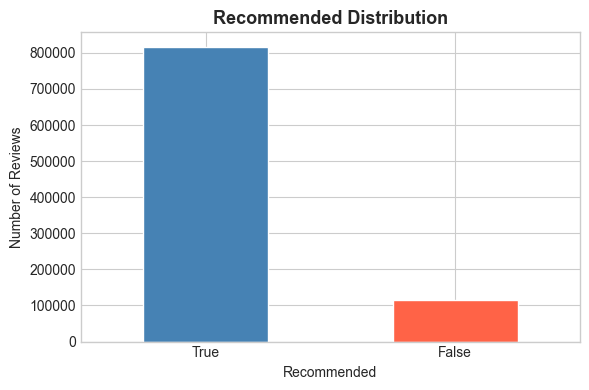

In [11]:
print("Recommended Distribution")
rec_counts = df['recommended'].value_counts()
rec_pct    = df['recommended'].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({'count': rec_counts, 'percent': rec_pct}))


plt.figure(figsize=(6, 4))
rec_counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Recommended Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Recommended')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Helpful Votes Distribution

The `votes_helpful` column is our helpfulness prediction target in future steps.
We inspect its distribution to understand how sparse helpful votes are across
the dataset, and define the binary threshold we will use for modeling.

A review is considered **helpful** if it has received at least 1 helpful vote.

Votes Helpful Distribution
count   931,695.00
mean          2.27
std          51.51
min           0.00
25%           0.00
50%           0.00
75%           1.00
max      16,960.00
Name: votes_helpful, dtype: float64

Reviews with ≥1 helpful vote : 298,483 (32.0%)
Reviews with 0 helpful votes : 633,212 (68.0%)


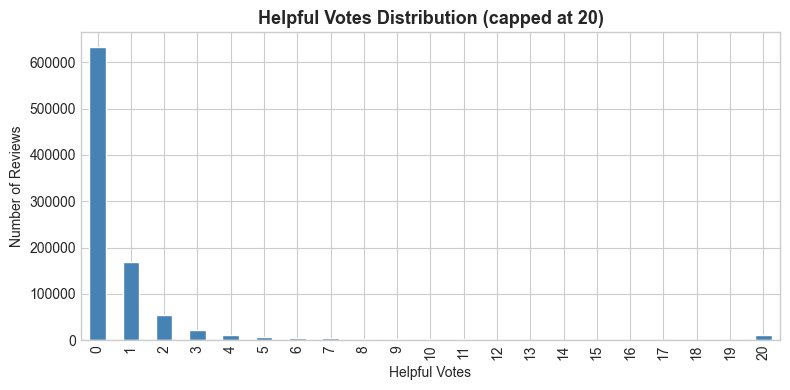

In [12]:
print("Votes Helpful Distribution")
print(df['votes_helpful'].describe())

helpful_count = (df['votes_helpful'] >= 1).sum()
helpful_pct   = (df['votes_helpful'] >= 1).mean() * 100
print(f"\nReviews with ≥1 helpful vote : {helpful_count:,} ({helpful_pct:.1f}%)")
print(f"Reviews with 0 helpful votes : {len(df) - helpful_count:,} ({100 - helpful_pct:.1f}%)")

# Visualize — cap at 20 for readability
plt.figure(figsize=(8, 4))
df['votes_helpful'].clip(upper=20).value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='white'
)
plt.title('Helpful Votes Distribution (capped at 20)', fontsize=13, fontweight='bold')
plt.xlabel('Helpful Votes')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

### Playtime at Review Distribution

`author.playtime_at_review` captures how many minutes a reviewer had played
the game at the time they wrote their review. This is a key behavioral feature
for our helpfulness model in Notebook 5.

We convert playtime from minutes to hours for readability, inspect the
distribution, and note the presence of outliers. Due to the heavy right skew
expected in this column, we compare mean vs median as a measure of skew.

Playtime at Review (hours)
count   930,443.00
mean        151.04
std         440.30
min           0.02
25%           9.88
50%          32.20
75%         114.37
max      34,530.13
Name: playtime_hours, dtype: float64


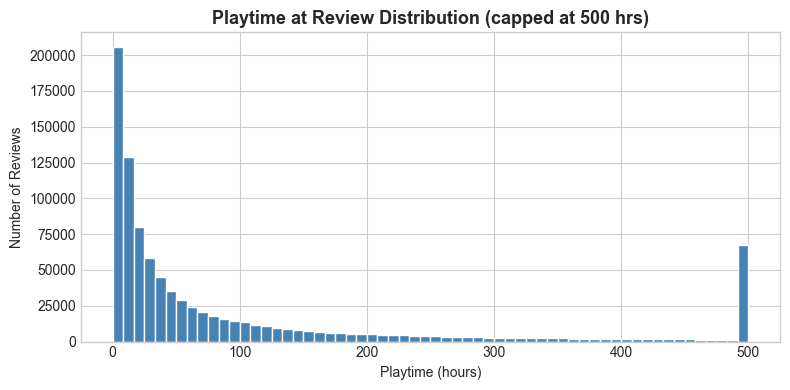

In [13]:
df['playtime_hours'] = (df['author.playtime_at_review'] / 60).round(2)

print("Playtime at Review (hours)")
print(df['playtime_hours'].describe())

plt.figure(figsize=(8, 4))
df['playtime_hours'].clip(upper=500).hist(
    bins=60, color='steelblue', edgecolor='white'
)
plt.title('Playtime at Review Distribution (capped at 500 hrs)',
          fontsize=13, fontweight='bold')
plt.xlabel('Playtime (hours)')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

### Per-Game Review Count Distribution

Since our sample was taken before language filtering, some games may now be
underrepresented if a large portion of their reviews were non-English.

We inspect the top and bottom games by review count to check for any
significant imbalance in game representation after the English filter.
This is important context for interpreting our topic modeling results in
Notebook 4, where dominant games could otherwise bias discovered topics.

Games in Dataset : 315

Top 10 games by review count:
app_name
Terraria                          32660
PLAYERUNKNOWN'S BATTLEGROUNDS     29954
Tom Clancy's Rainbow Six Siege    29505
Garry's Mod                       29358
Grand Theft Auto V                27303
Rust                              25713
Among Us                          23209
Rocket League                     21796
ARK: Survival Evolved             17967
PAYDAY 2                          17913
Name: count, dtype: int64

Bottom 10 games by review count:
app_name
Farm Manager 2018                        67
Out of the Park Baseball 19              62
Fairy Fencer F Advent Dark Force         62
Toukiden 2                               60
Shadow Complex Remastered                42
DRAGON QUEST HEROES™ II                  35
Battle Royale Trainer                    27
Senren＊Banka                             25
Neon Hardcorps                            6
三国群英传8 Heroes of the Three Kingdoms 8     2
Name: count, dtype: int64


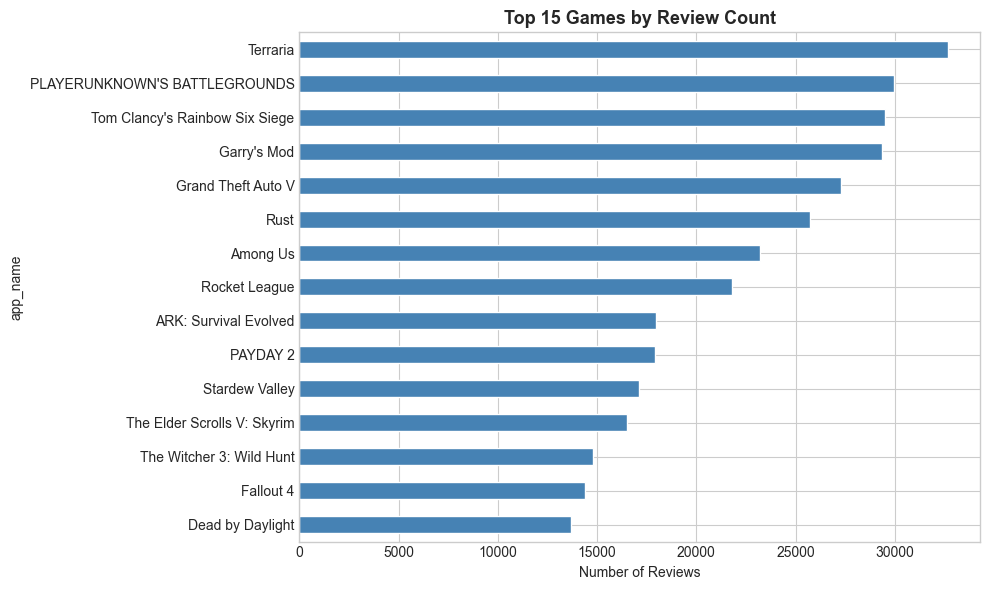

In [14]:
game_counts = df['app_name'].value_counts()

print(f"Games in Dataset : {game_counts.shape[0]}")
print(f"\nTop 10 games by review count:")
print(game_counts.head(10))
print(f"\nBottom 10 games by review count:")
print(game_counts.tail(10))

# Visualize top 15
plt.figure(figsize=(10, 6))
game_counts.head(15).plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 15 Games by Review Count', fontsize=13, fontweight='bold')
plt.xlabel('Number of Reviews')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Save Clean Base File

We save the cleaned, filtered dataset as a new parquet file before proceeding
to Notebook 2. This checkpoint means Notebook 1 never needs to be re-run, all subsequent chapters load directly from this file.

The saved file contains only English reviews that passed all quality checks,
with the 8 columns needed for text mining plus the derived `playtime_hours`
column.

In [15]:
output_path = '../data/steam_text_mining_base.parquet'
df.to_parquet(output_path, index=False)

print(f"Clean base file saved : steam_text_mining_base.parquet")
print(f"Rows    : {len(df):,}")
print(f"Columns : {df.shape[1]}")
print(f"Size    : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Clean base file saved : steam_text_mining_base.parquet
Rows    : 931,695
Columns : 10
Size    : 333.2 MB


## Data Loading and Initial Exploration Summary

| Step | Result |
|---|---|
| Source file | Teammate's pre-sampled parquet (12% per app_id) |
| Rows loaded | ~2,600,000 |
| Columns selected | 8 |
| Rows after English filter + null/junk removal | 931,695 |
| Unique games | 315 |
| Positive recommendations | 87.6% (816,180) |
| Negative recommendations | 12.4% (115,515) |
| Reviews with ≥1 helpful vote | 32.0% (298,483) |
| Reviews with 0 helpful votes | 68.0% (633,212) |
| Median playtime at review | 32.20 hours |
| Mean playtime at review | 151.04 hours |

**Key Observations:**

1. **Class Imbalance:** 87.6% of reviews are positive recommendations.
   This is a significant imbalance that must be accounted for during
   modeling in Chapter 5 using `class_weight='balanced'` and F1-score
   as the primary evaluation metric rather than accuracy alone.

2. **Helpfulness Sparsity:** 68% of reviews have zero helpful votes,
   meaning most reviews go unnoticed by the community. The helpfulness
   target will be binarized as `votes_helpful ≥ 1` for Chapter 5.
   A small number of reviews are highly viral (max: 16,960 votes),
   causing a large gap between mean (2.27) and median (0).

3. **Playtime Skew:** Median playtime at review is 32.20 hours but
   the mean is 151.04 hours, indicating heavy right skew driven by
   extreme outliers (max: ~34,530 hours). The median better represents
   the typical reviewer. Playtime will be capped at the 99th percentile
   during feature engineering in Notebook 5.

4. **Game Representation Imbalance (Limitation):** After applying the
   English filter, game representation varies dramatically — from
   32,660 reviews (Terraria) to just 2 reviews. Games
   with predominantly non-English review bases are heavily
   underrepresented. This is an inherent limitation of applying a
   language filter to a globally sampled dataset and will be noted
   when interpreting topic modeling results in Notebook 4.

**Output:** `steam_text_mining_base.parquet`